# Dự báo lượng khách di sản Huế — Lựa chọn mô hình theo tầm dự báo (v5, 3 điểm × 10 hạt giống)

**Bài toán.** Dự báo lượng khách hằng ngày tại **3 điểm di tích Cố đô Huế** (Đại Nội, Lăng Minh Mạng, Lăng Khải Định) và **chọn mô hình theo từng khoảng thời gian dự báo**
thay vì một mô hình "tốt nhất" chung. Kết quả cho thấy **RandomForest hiệu quả cho dự báo 1 ngày kế tiếp**,
còn **TFT hiệu quả cho dự báo trung–dài hạn (7 & 30 ngày)**.

**Thiết kế.**
- Tầm dự báo: **1 / 7 / 30 ngày**; mục tiêu `visitors = domestic + international` (mô hình hoá `log1p`, đo trên thang gốc).
- Mô hình: `SeasonalNaive-7` (baseline), `ETS`, `SARIMAX`, `ARIMAX`, `RF`, `LSTM`, `DLM`, `TFT`.
- Đánh giá: rolling-origin trên khối test; huấn luyện **một lần** (thống kê dùng `apply`, ML/DL đệ quy) — so sánh công bằng.
- **Độ bền:** lặp lại với **10 hạt giống** → báo cáo trung bình ± khoảng tin cậy 95%.
- **Lựa chọn:** MAE/RMSE/MAPE theo **từng tầm** → mô hình vô địch cho mỗi tầm.
- **Kiểm định thống kê:** Diebold–Mariano (đôi một) **và Model Confidence Set (MCS)** — tập mô hình vượt trội.
- **Dự báo xác suất:** đánh giá **phân vị của TFT** bằng pinball loss + độ phủ khoảng (PICP 80%/95%).
- **Giải thích:** SHAP trên RandomForest (động lực cầu). **Chi phí tính toán** cho từng mô hình.

> ⏱️ **Lưu ý thời gian chạy:** 3 điểm × 10 hạt giống — nên chạy trên **GPU** (Colab). Để thử nhanh, đặt `QUICK_MODE=True` ở Mục 1.
>
> **Nhãn tiếng Anh:** mọi tiêu đề hình, nhãn trục và tên cột bảng xuất ra đều bằng **tiếng Anh** (kèm tên điểm: Imperial City / Minh Mang Tomb / Khai Dinh Tomb) để đưa thẳng vào bài báo. Các CSV bảng có thêm cột `site` (tên tiếng Anh); file hình dùng tên ASCII (`dai_noi`, `minh_mang`, `khai_dinh`).
>
> *Không sử dụng biến ngoại sinh (đưa vào Future work). Không dùng/không đề cập bó mô hình phức hợp.*

## 1. Cài đặt môi trường

In [1]:
%pip -q install "pytorch-forecasting>=1.0" "lightning>=2.1" optuna holidays statsmodels scikit-learn shap tbats arch 2>/dev/null
%pip -q install pmdarima 2>/dev/null || echo "pmdarima optional - statsmodels used"
print("Dependencies installed.")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.3/425.3 kB 30.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 848.6/848.6 kB 55.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 36.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 982.9/982.9 kB 54.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 267.4/267.4 kB 26.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 165.3/165.3 kB 15.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 63.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 688.9/688.9 kB 46.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 852.4/852.4 kB 52.3 MB/s eta 0:00:00
Dependencies installed.


In [2]:
import warnings, os, math, json, glob, time, random
warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import torch
print("torch", torch.__version__, "| CUDA:", torch.cuda.is_available())
from google.colab import drive
drive.mount('/content/drive')

torch 2.11.0+cu128 | CUDA: True
Mounted at /content/drive


In [3]:
CONFIG = {
    "DATA_DIR":   "/content/drive/MyDrive/Hue_DEFI2026/data",
    "OUTPUT_DIR": "/content/drive/MyDrive/Hue_DEFI2026/outputs_v5",
    "USE_LOG_TARGET": True,
    "MAX_ENCODER_LENGTH": 30,
    "HORIZONS": [1, 7, 30],
    "SEED": 42,
    # >>> NÂNG CẤP 1: 10 hạt giống cho kiểm định độ bền
    "SEEDS": [42, 7, 123, 2024, 1, 99, 256, 512, 77, 2025],
    "TFT_TUNE": True,
    "TUNE_TRIALS": 10,
    "TUNE_EPOCHS": 8,
    "MAX_EPOCHS": 30,
    "BATCH_SIZE": 128,
    # >>> v5: chỉ 3 điểm (loại Lăng Tự Đức). Tên phải khớp cột "destination" trong dữ liệu.
    "DESTINATIONS": ["Đại Nội", "Lăng vua Minh Mạng", "Lăng vua Khải Định"],
    "MODELS": ["SeasonalNaive7","ETS","SARIMAX","ARIMAX","RF","LSTM","DLM","TFT"],
    # >>> NÂNG CẤP 3: lượng tử cho đánh giá xác suất của TFT (khớp QuantileLoss mặc định)
    "TFT_QUANTILES": [0.02, 0.1, 0.25, 0.5, 0.75, 0.9, 0.98],
    # >>> NÂNG CẤP 4: tham số Model Confidence Set
    "MCS_SIZE": 0.10,     # mức ý nghĩa (giữ lại tập vượt trội 90%)
    "MCS_REPS": 1000     # số lần bootstrap
}
# TBATS bị loại khỏi mặc định vì phải tái ước lượng ở mỗi gốc (rất chậm với nhiều điểm).
# Muốn thêm: chèn "TBATS" vào CONFIG["MODELS"].

QUICK_MODE = False   # True = chạy nhanh (1 điểm, 3 seed, ít epoch) để debug
if QUICK_MODE:
    CONFIG.update({"DESTINATIONS":["Đại Nội"], "SEEDS":[42,7,123],
                   "TUNE_TRIALS":4, "TUNE_EPOCHS":5, "MAX_EPOCHS":12})

H_MAX=max(CONFIG["HORIZONS"])
for sub in ["tables","figures","predictions","models"]:
    os.makedirs(os.path.join(CONFIG["OUTPUT_DIR"],sub),exist_ok=True)
def set_seed(s=CONFIG["SEED"]):
    random.seed(s); np.random.seed(s); torch.manual_seed(s)
    if torch.cuda.is_available(): torch.cuda.manual_seed_all(s)
set_seed()

# ==== ENGLISH LABELS for figures & tables (drop straight into the English paper) ====
DEST_EN = {"Đại Nội":"Imperial City (Dai Noi)","Lăng vua Minh Mạng":"Minh Mang Tomb",
           "Lăng vua Khải Định":"Khai Dinh Tomb","Lăng vua Tự Đức":"Tu Duc Tomb"}
DEST_SLUG = {"Đại Nội":"dai_noi","Lăng vua Minh Mạng":"minh_mang",
             "Lăng vua Khải Định":"khai_dinh","Lăng vua Tự Đức":"tu_duc"}
def en(dst):   return DEST_EN.get(dst, str(dst))     # English site label for titles
def slug(dst): return DEST_SLUG.get(dst, str(dst))   # ASCII filename token

print("Điểm đến     :", CONFIG["DESTINATIONS"] or "TẤT CẢ trong DATA_DIR")
print("Số hạt giống :", len(CONFIG["SEEDS"]))
print("Mô hình      :", CONFIG["MODELS"])
CONFIG

Điểm đến     : ['Đại Nội', 'Lăng vua Minh Mạng', 'Lăng vua Khải Định']
Số hạt giống : 10
Mô hình      : ['SeasonalNaive7', 'ETS', 'SARIMAX', 'ARIMAX', 'RF', 'LSTM', 'DLM', 'TFT']


{'DATA_DIR': '/content/drive/MyDrive/Hue_DEFI2026/data',
 'OUTPUT_DIR': '/content/drive/MyDrive/Hue_DEFI2026/outputs_v5',
 'USE_LOG_TARGET': True,
 'MAX_ENCODER_LENGTH': 30,
 'HORIZONS': [1, 7, 30],
 'SEED': 42,
 'SEEDS': [42, 7, 123, 2024, 1, 99, 256, 512, 77, 2025],
 'TFT_TUNE': True,
 'TUNE_TRIALS': 10,
 'TUNE_EPOCHS': 8,
 'MAX_EPOCHS': 30,
 'BATCH_SIZE': 128,
 'DESTINATIONS': ['Đại Nội', 'Lăng vua Minh Mạng', 'Lăng vua Khải Định'],
 'MODELS': ['SeasonalNaive7',
  'ETS',
  'SARIMAX',
  'ARIMAX',
  'RF',
  'LSTM',
  'DLM',
  'TFT'],
 'TFT_QUANTILES': [0.02, 0.1, 0.25, 0.5, 0.75, 0.9, 0.98],
 'MCS_SIZE': 0.1,
 'MCS_REPS': 1000}

## 2. Nạp dữ liệu & đặc trưng (lịch + ngày lễ Việt Nam)

In [4]:
import holidays as pyholidays
from sklearn.impute import KNNImputer

def load_destinations(data_dir):
    files=sorted(glob.glob(os.path.join(data_dir,"*daily_visitors_clean*.csv"))) or \
          sorted(glob.glob(os.path.join(data_dir,"*.csv")))
    frames=[]
    for f in files:
        d=pd.read_csv(f)
        if "visitors" in d.columns: frames.append(d)
    df=pd.concat(frames,ignore_index=True)
    df["date"]=pd.to_datetime(df["date"])
    return df.sort_values(["destination","date"]).reset_index(drop=True)

def make_regular(df):
    out=[]
    for dst,g in df.groupby("destination"):
        g=g.set_index("date").sort_index()
        g=g.reindex(pd.date_range(g.index.min(),g.index.max(),freq="D"))
        g["destination"]=dst
        for col in ["domestic_visitors","international_visitors","visitors"]:
            if g[col].isna().any():
                ctx=pd.DataFrame({"v":g[col].values,"doy":g.index.dayofyear,"dow":g.index.dayofweek})
                g[col]=KNNImputer(n_neighbors=7).fit_transform(ctx)[:,0]
        g["visitors"]=g["visitors"].clip(lower=0).round()
        out.append(g.reset_index().rename(columns={"index":"date"}))
    return pd.concat(out,ignore_index=True)

def add_features(df):
    df=df.sort_values(["destination","date"]).copy()
    yrs=range(df["date"].dt.year.min(),df["date"].dt.year.max()+1)
    vn=pyholidays.Vietnam(years=list(yrs)); hdays=pd.to_datetime(sorted(vn.keys()))
    df["day"]=df["date"].dt.day; df["month"]=df["date"].dt.month; df["year"]=df["date"].dt.year
    df["weekday"]=df["date"].dt.weekday; df["dayofyear"]=df["date"].dt.dayofyear
    df["weekofyear"]=df["date"].dt.isocalendar().week.astype(int)
    df["is_weekend"]=(df["weekday"]>=5).astype(int)
    df["holiday"]=df["date"].isin(vn).astype(int)
    df["days_to_holiday"]=df["date"].apply(lambda d:int(min(abs((d-hdays).days))) if len(hdays) else 30).clip(upper=30)
    df["time_idx"]=df.groupby("destination").cumcount()
    return df

raw=load_destinations(CONFIG["DATA_DIR"])
if CONFIG["DESTINATIONS"]: raw=raw[raw["destination"].isin(CONFIG["DESTINATIONS"])].copy()
data=add_features(make_regular(raw))
# reuse provided split labels; recompute 70/15/15 if absent
if "split" not in data.columns or data["split"].isna().any():
    def relabel(g):
        n=len(g); g=g.sort_values("date"); tr=int(.7*n); va=int(.85*n)
        g["split"]=["train"]*tr+["validation"]*(va-tr)+["test"]*(n-va); return g
    data=data.groupby("destination",group_keys=False).apply(relabel)
print(data.groupby(["destination","split"]).size().unstack(fill_value=0))
data[["date","destination","visitors","holiday","weekday","time_idx","split"]].head()

split               test  train  validation
destination                                
Lăng vua Khải Định   210    975         208
Lăng vua Minh Mạng   210    975         208
Đại Nội              210    975         208


,date,destination,visitors,holiday,weekday,time_idx,split
0,2022-11-01,Lăng vua Khải Định,0,0,1,0,train
1,2022-11-02,Lăng vua Khải Định,0,0,2,1,train
2,2022-11-03,Lăng vua Khải Định,0,0,3,2,train
3,2022-11-04,Lăng vua Khải Định,0,0,4,3,train
4,2022-11-05,Lăng vua Khải Định,0,0,5,4,train


## 3. Chỉ số đánh giá & kiểm định Diebold–Mariano

In [5]:
def metrics(y_true,y_pred):
    y_true=np.asarray(y_true,float); y_pred=np.asarray(y_pred,float); err=y_pred-y_true
    mse=np.mean(err**2); nz=y_true>0
    ss=np.sum((y_true-y_true.mean())**2)
    return {"MAE":np.mean(np.abs(err)),"RMSE":math.sqrt(mse),"MSE":mse,
            "MAPE":(np.mean(np.abs(err[nz]/y_true[nz]))*100 if nz.any() else np.nan),
            "R2":(1-np.sum(err**2)/ss if ss>0 else np.nan)}

def diebold_mariano(y,p1,p2,h=1,power=2):
    from scipy.stats import t as tdist
    y=np.asarray(y,float); p1=np.asarray(p1,float); p2=np.asarray(p2,float)
    d=np.abs(y-p1)**power-np.abs(y-p2)**power; n=len(d); dbar=d.mean()
    gamma=[np.sum((d[k:]-dbar)*(d[:n-k]-dbar))/n for k in range(h)]
    var=(gamma[0]+2*sum(gamma[1:]))/n if h>1 else gamma[0]/n
    if var<=0: return np.nan,np.nan
    dm=dbar/math.sqrt(var); corr=math.sqrt((n+1-2*h+h*(h-1)/n)/n); dm*=corr
    return dm, 2*tdist.cdf(-abs(dm),df=n-1)

## 4. Mô hình benchmark (thống kê / ML / DL)

`SeasonalNaive-7` (baseline), `ETS`, `SARIMAX`, `ARIMAX` (biến lịch+lễ), `RF`, `LSTM`, `DLM`, `TBATS`.
Mô hình thống kê được *áp dụng lại* (không tái ước lượng) lên lịch sử tăng dần tại mỗi gốc; ML/DL dự báo đệ quy.
RandomForest dùng ma trận lag+lịch (tái sử dụng cho SHAP ở Mục 7).

In [6]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
try:
    from statsmodels.tsa.exponential_smoothing.ets import ETSModel
except Exception:
    ETSModel=None
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from sklearn.ensemble import RandomForestRegressor
import torch.nn as nn

LAG_SET=[1,2,3,4,5,6,7,14,21,28]
CAL_FEATS=["weekday","month","day","dayofyear","is_weekend","holiday","days_to_holiday"]
EXOG=["holiday","is_weekend","days_to_holiday","weekday","month"]
FEATURES=[f"lag_{L}" for L in LAG_SET]+CAL_FEATS

def hist_log(g,t0):  # observed log1p history strictly before origin t0
    return np.log1p(g.loc[g.time_idx<t0,"visitors"].values)

# ---------- statistical models: fit once on train+val, apply() to history ----------
def fit_stat(g,kind):
    tv=g[g.split!="test"]; y=np.log1p(tv["visitors"].values)
    if kind=="ETS":
        try: res=ETSModel(y,error="add",trend="add",seasonal="add",seasonal_periods=7).fit(disp=False)
        except Exception: res=ExponentialSmoothing(y,trend="add",seasonal="add",seasonal_periods=7).fit()
    elif kind=="SARIMAX":
        res=SARIMAX(y,order=(2,1,1),seasonal_order=(1,0,1,7),
                    enforce_stationarity=False,enforce_invertibility=False).fit(disp=False)
    elif kind=="ARIMAX":
        res=SARIMAX(y,exog=tv[EXOG].values,order=(2,1,1),
                    enforce_stationarity=False,enforce_invertibility=False).fit(disp=False)
    return res

def stat_forecast(res,kind,g,t0):
    y=hist_log(g,t0)
    fut=g[(g.time_idx>=t0)&(g.time_idx<t0+H_MAX)][EXOG].values
    try:
        if kind=="ARIMAX":
            r2=res.apply(y,exog=g[g.time_idx<t0][EXOG].values); fc=r2.forecast(H_MAX,exog=fut)
        elif kind=="SARIMAX":
            r2=res.apply(y); fc=r2.forecast(H_MAX)
        else:  # ETS
            r2=res.apply(y); fc=r2.forecast(H_MAX)
    except Exception:  # fallback: refit on history
        if kind=="ARIMAX":
            r=SARIMAX(y,exog=g[g.time_idx<t0][EXOG].values,order=(2,1,1),
                      enforce_stationarity=False,enforce_invertibility=False).fit(disp=False)
            fc=r.forecast(H_MAX,exog=fut)
        elif kind=="SARIMAX":
            fc=SARIMAX(y,order=(2,1,1),seasonal_order=(1,0,1,7),
                       enforce_stationarity=False,enforce_invertibility=False).fit(disp=False).forecast(H_MAX)
        else:
            fc=ExponentialSmoothing(y,trend="add",seasonal="add",seasonal_periods=7).fit().forecast(H_MAX)
    return np.expm1(np.asarray(fc))

# ---------- seasonal naive ----------
def snaive_forecast(g,t0):
    ext=list(hist_log(g,t0)); out=[]
    for h in range(H_MAX):
        out.append(ext[-7] if len(ext)>=7 else ext[-1]); ext.append(out[-1])
    return np.expm1(np.array(out))

# ---------- RandomForest with explicit feature matrix (reused for SHAP) ----------
def build_feature_frame(g):
    g=g.sort_values("time_idx").copy(); yz=np.log1p(g["visitors"].values)
    s=pd.Series(yz,index=g.index)
    for L in LAG_SET: g[f"lag_{L}"]=s.shift(L).values
    g["y_log"]=yz; return g

def fit_rf(g):
    gf=build_feature_frame(g).dropna(subset=FEATURES)
    tr=gf[gf.split!="test"]
    rf=RandomForestRegressor(n_estimators=300,max_depth=14,n_jobs=-1,
                             random_state=CONFIG["SEED"]).fit(tr[FEATURES].values,tr["y_log"].values)
    return rf, gf

def rf_forecast(rf,g,t0):
    ext=list(hist_log(g,t0)); cal=g.set_index("time_idx"); out=[]
    for h in range(1,H_MAX+1):
        ti=t0+h-1
        feat=[(ext[-L] if len(ext)>=L else ext[0]) for L in LAG_SET]+[cal.loc[ti,c] for c in CAL_FEATS]
        p=rf.predict(np.array(feat).reshape(1,-1))[0]; out.append(p); ext.append(p)
    return np.expm1(np.array(out))

# ---------- LSTM & DLM (autoregressive, z-scored log space) ----------
class SeqLSTM(nn.Module):
    def __init__(s,h=32): super().__init__(); s.l=nn.LSTM(1,h,batch_first=True); s.f=nn.Linear(h,1)
    def forward(s,x): o,_=s.l(x); return s.f(o[:,-1])
class MLP(nn.Module):
    def __init__(s,L,h=64): super().__init__(); s.n=nn.Sequential(nn.Linear(L,h),nn.ReLU(),nn.Linear(h,h),nn.ReLU(),nn.Linear(h,1))
    def forward(s,x): return s.n(x)
def _lagmat(y,L):
    X=[y[i-L:i] for i in range(L,len(y))]; Y=[y[i] for i in range(L,len(y))]
    return np.array(X),np.array(Y)
def fit_torch(g,kind):
    L=CONFIG["MAX_ENCODER_LENGTH"]; y=np.log1p(g[g.split!="test"]["visitors"].values)
    mu,sd=y.mean(),y.std()+1e-8; yz=(y-mu)/sd; X,Y=_lagmat(yz,L)
    dev="cuda" if torch.cuda.is_available() else "cpu"
    model=(SeqLSTM() if kind=="LSTM" else MLP(L)).to(dev)
    opt=torch.optim.Adam(model.parameters(),lr=1e-2); lf=nn.MSELoss()
    Xt=torch.tensor(X,dtype=torch.float32).to(dev);
    if kind=="LSTM": Xt=Xt.unsqueeze(-1)
    Yt=torch.tensor(Y,dtype=torch.float32).view(-1,1).to(dev)
    model.train()
    for _ in range(80): opt.zero_grad(); lf(model(Xt),Yt).backward(); opt.step()
    return (model,dev,mu,sd,L,kind)
def torch_forecast(state,g,t0):
    model,dev,mu,sd,L,kind=state
    ext=list(((hist_log(g,t0)-mu)/sd)); out=[]; model.eval()
    with torch.no_grad():
        for _ in range(H_MAX):
            x=torch.tensor(np.array(ext[-L:]),dtype=torch.float32).view(1,-1).to(dev)
            if kind=="LSTM": x=x.unsqueeze(-1)
            p=model(x).item(); out.append(p); ext.append(p)
    return np.expm1(np.array(out)*sd+mu)

def fit_tbats(g):
    from tbats import TBATS
    y=np.log1p(g[g.split!="test"]["visitors"].values)
    return TBATS(seasonal_periods=[7],use_box_cox=False,use_arma_errors=False,n_jobs=1).fit(y)
def tbats_forecast(model,g,t0):
    # refit on history (TBATS has no cheap apply); guarded/optional in QUICK_MODE
    from tbats import TBATS
    y=hist_log(g,t0)
    m=TBATS(seasonal_periods=[7],use_box_cox=False,use_arma_errors=False,n_jobs=1).fit(y)
    return np.expm1(m.forecast(steps=H_MAX))

In [7]:
def rolling_eval(g,forecast_fn,name):
    key=g.set_index("time_idx")["visitors"]
    test_idx=sorted(g.loc[g.split=="test","time_idx"].tolist())
    origins=[t for t in test_idx if (t-1) in key.index]
    recs=[]
    for t0 in origins:
        try: fc=forecast_fn(g,t0)
        except Exception: continue
        for h in CONFIG["HORIZONS"]:
            ti=t0+h-1
            if ti in key.index:
                recs.append({"destination":g["destination"].iloc[0],"origin":t0,"horizon":h,
                             "y_true":float(key.loc[ti]),"y_pred":float(max(fc[h-1],0)),"model":name})
    return pd.DataFrame(recs)

In [8]:
# === 4.1 Chạy benchmarks đa hạt giống + đo chi phí tính toán ===
import time
def _t(): return time.time()

DET = [m for m in CONFIG["MODELS"] if m in ("SeasonalNaive7","ETS","SARIMAX","ARIMAX","TBATS")]
STO = [m for m in CONFIG["MODELS"] if m in ("RF","LSTM","DLM")]
_ORIG_SEED = CONFIG["SEED"]

def _stat_fn(name, g):
    res = fit_stat(g, name); return lambda gg,t0,_r=res,_k=name: stat_forecast(_r,_k,gg,t0)

bench_rows, cost_rows, rf_store = [], [], {}
for dst in data["destination"].unique():
    g = data[data["destination"]==dst].copy()

    # ---- mô hình xác định: chạy 1 lần, nhân bản cho mọi seed ----
    for name in DET:
        t0=_t()
        if name=="SeasonalNaive7": fn=snaive_forecast
        elif name in ("ETS","SARIMAX","ARIMAX"): fn=_stat_fn(name,g)
        elif name=="TBATS": _=fit_tbats(g); fn=lambda gg,t0_: tbats_forecast(None,gg,t0_)
        fit_s=_t()-t0
        t1=_t(); r=rolling_eval(g,fn,name); inf_s=_t()-t1
        cost_rows.append({"destination":dst,"model":name,"seed":"det","fit_seconds":fit_s,"infer_seconds":inf_s,"n_preds":len(r)})
        for s in CONFIG["SEEDS"]:
            rr=r.copy(); rr["seed"]=s; bench_rows.append(rr)
        print(f"[det ] {name:14s} {dst} | fit={fit_s:6.1f}s infer={inf_s:6.1f}s")

    # ---- mô hình ngẫu nhiên: mỗi seed một lần (RF đọc CONFIG['SEED']) ----
    for s in CONFIG["SEEDS"]:
        set_seed(s); CONFIG["SEED"]=s
        for name in STO:
            set_seed(s); t0=_t()
            if name=="RF":
                rf,gf=fit_rf(g); rf_store.setdefault(dst,(rf,gf))   # RF seed đầu -> dùng cho SHAP
                fn=lambda gg,t0_,_m=rf: rf_forecast(_m,gg,t0_)
            else:
                st=fit_torch(g,name); fn=lambda gg,t0_,_s=st: torch_forecast(_s,gg,t0_)
            fit_s=_t()-t0
            t1=_t(); r=rolling_eval(g,fn,name); inf_s=_t()-t1
            r["seed"]=s; bench_rows.append(r)
            cost_rows.append({"destination":dst,"model":name,"seed":s,"fit_seconds":fit_s,"infer_seconds":inf_s,"n_preds":len(r)})
            print(f"[s={s:<3}] {name:14s} {dst} | fit={fit_s:6.1f}s infer={inf_s:6.1f}s")
CONFIG["SEED"]=_ORIG_SEED
bench_multi = pd.concat(bench_rows, ignore_index=True)
print("\nbench_multi:", bench_multi.shape)

[det ] SeasonalNaive7 Lăng vua Khải Định | fit=   0.0s infer=   0.1s
[det ] ETS            Lăng vua Khải Định | fit=   0.4s infer=  75.7s


/usr/local/lib/python3.13/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


[det ] SARIMAX        Lăng vua Khải Định | fit=   2.2s infer=   3.2s


/usr/local/lib/python3.13/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.13/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.13/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.13/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.13/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood op

[det ] ARIMAX         Lăng vua Khải Định | fit=   2.3s infer=  78.9s
[s=42 ] RF             Lăng vua Khải Định | fit=   1.0s infer= 399.2s
[s=42 ] LSTM           Lăng vua Khải Định | fit=   6.5s infer=   2.9s
[s=42 ] DLM            Lăng vua Khải Định | fit=   0.2s infer=   1.9s
[s=7  ] RF             Lăng vua Khải Định | fit=   0.9s infer= 399.0s
[s=7  ] LSTM           Lăng vua Khải Định | fit=   0.2s infer=   2.6s
[s=7  ] DLM            Lăng vua Khải Định | fit=   0.1s infer=   1.8s
[s=123] RF             Lăng vua Khải Định | fit=   1.0s infer= 398.6s
[s=123] LSTM           Lăng vua Khải Định | fit=   0.2s infer=   2.5s
[s=123] DLM            Lăng vua Khải Định | fit=   0.1s infer=   1.7s
[s=2024] RF             Lăng vua Khải Định | fit=   0.9s infer= 397.4s
[s=2024] LSTM           Lăng vua Khải Định | fit=   0.2s infer=   2.6s
[s=2024] DLM            Lăng vua Khải Định | fit=   0.1s infer=   1.8s
[s=1  ] RF             Lăng vua Khải Định | fit=   1.0s infer= 398.7s
[s=1  ] LSTM      

/usr/local/lib/python3.13/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


[det ] SARIMAX        Đại Nội | fit=   1.9s infer=   4.3s


/usr/local/lib/python3.13/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.13/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.13/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.13/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.13/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood op

[det ] ARIMAX         Đại Nội | fit=   2.3s infer=  80.7s
[s=42 ] RF             Đại Nội | fit=   1.1s infer= 397.5s
[s=42 ] LSTM           Đại Nội | fit=   0.2s infer=   2.8s
[s=42 ] DLM            Đại Nội | fit=   0.1s infer=   1.8s
[s=7  ] RF             Đại Nội | fit=   1.0s infer= 398.0s
[s=7  ] LSTM           Đại Nội | fit=   0.2s infer=   2.8s
[s=7  ] DLM            Đại Nội | fit=   0.1s infer=   1.8s
[s=123] RF             Đại Nội | fit=   1.0s infer= 399.7s
[s=123] LSTM           Đại Nội | fit=   0.2s infer=   2.6s
[s=123] DLM            Đại Nội | fit=   0.1s infer=   1.8s
[s=2024] RF             Đại Nội | fit=   0.9s infer= 400.5s
[s=2024] LSTM           Đại Nội | fit=   0.2s infer=   2.9s
[s=2024] DLM            Đại Nội | fit=   0.1s infer=   1.7s
[s=1  ] RF             Đại Nội | fit=   1.0s infer= 399.0s
[s=1  ] LSTM           Đại Nội | fit=   0.2s infer=   2.7s
[s=1  ] DLM            Đại Nội | fit=   0.1s infer=   1.8s
[s=99 ] RF             Đại Nội | fit=   0.9s infer= 39

## 5. Mô hình TFT (Temporal Fusion Transformer) — đa hạt giống

In [9]:
import lightning.pytorch as pl
from lightning.pytorch.callbacks import EarlyStopping
from pytorch_forecasting import TimeSeriesDataSet, TemporalFusionTransformer
from pytorch_forecasting.data import GroupNormalizer
from pytorch_forecasting.metrics import QuantileLoss
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

TARGET="log1p_visitors" if CONFIG["USE_LOG_TARGET"] else "visitors"
data["log1p_visitors"]=np.log1p(data["visitors"])
KNOWN=["time_idx","day","month","year","weekday","dayofyear","weekofyear","is_weekend","holiday","days_to_holiday"]

def build_datasets(df):
    max_tr=df.loc[df.split=="train","time_idx"].max()
    max_va=df.loc[df.split.isin(["train","validation"]),"time_idx"].max()
    training=TimeSeriesDataSet(df[df.time_idx<=max_va],time_idx="time_idx",target=TARGET,
        group_ids=["destination"],max_encoder_length=CONFIG["MAX_ENCODER_LENGTH"],max_prediction_length=H_MAX,
        static_categoricals=["destination"],time_varying_known_reals=KNOWN,
        time_varying_unknown_reals=[TARGET],target_normalizer=GroupNormalizer(groups=["destination"]),
        add_relative_time_idx=True,add_target_scales=True,allow_missing_timesteps=True)
    validation=TimeSeriesDataSet.from_dataset(training,df[df.time_idx<=max_va],predict=False,
        stop_randomization=True,min_prediction_idx=max_tr-H_MAX+1)
    return training,validation,max_va

def make_tft(training,p):
    return TemporalFusionTransformer.from_dataset(training,learning_rate=p["learning_rate"],
        hidden_size=p["hidden_size"],attention_head_size=p["attention_head_size"],dropout=p["dropout"],
        hidden_continuous_size=min(p["hidden_continuous_size"],p["hidden_size"]),
        loss=QuantileLoss(),log_interval=0,optimizer="adam")

def train_tft(training,validation,p,epochs):
    set_seed()
    tl=training.to_dataloader(train=True,batch_size=CONFIG["BATCH_SIZE"],num_workers=0)
    vl=validation.to_dataloader(train=False,batch_size=256,num_workers=0)
    tft=make_tft(training,p)
    trainer=pl.Trainer(max_epochs=epochs,accelerator="gpu" if torch.cuda.is_available() else "cpu",devices=1,
        gradient_clip_val=0.1,enable_progress_bar=False,enable_model_summary=False,logger=False,
        enable_checkpointing=False,callbacks=[EarlyStopping(monitor="val_loss",patience=6,mode="min")])
    trainer.fit(tft,tl,vl); return tft,trainer

def tune_tft(training,validation):
    if not CONFIG["TFT_TUNE"]:
        return {"learning_rate":0.01,"hidden_size":32,"attention_head_size":2,"dropout":0.15,"hidden_continuous_size":16}
    def obj(tr):
        p=dict(learning_rate=tr.suggest_float("learning_rate",1e-3,1e-1,log=True),
               hidden_size=tr.suggest_categorical("hidden_size",[16,32,64]),
               attention_head_size=tr.suggest_categorical("attention_head_size",[1,2,4]),
               dropout=tr.suggest_float("dropout",0.1,0.3),
               hidden_continuous_size=tr.suggest_categorical("hidden_continuous_size",[8,16,32]))
        try: _,t=train_tft(training,validation,p,CONFIG["TUNE_EPOCHS"]); return t.callback_metrics["val_loss"].item()
        except Exception: return float("inf")
    st=optuna.create_study(direction="minimize",sampler=optuna.samplers.RandomSampler(seed=CONFIG["SEED"]))
    st.optimize(obj,n_trials=CONFIG["TUNE_TRIALS"],show_progress_bar=False)
    print("  best val_loss=%.4f"%st.best_value); return st.best_params

def tft_predict_test(tft,df):
    max_va=df.loc[df.split.isin(["train","validation"]),"time_idx"].max()
    training,_,_=build_datasets(df)
    test_ds=TimeSeriesDataSet.from_dataset(training,df,predict=False,stop_randomization=True,min_prediction_idx=max_va+1)
    out=tft.predict(test_ds.to_dataloader(train=False,batch_size=256,num_workers=0),mode="prediction",return_index=True)
    preds=out.output.cpu().numpy() if hasattr(out.output,"cpu") else np.asarray(out.output)
    if CONFIG["USE_LOG_TARGET"]: preds=np.expm1(preds)
    idx=out.index.reset_index(drop=True); key=df.set_index(["destination","time_idx"])["visitors"]; recs=[]
    for i,row in idx.iterrows():
        dst=row["destination"]; t0=int(row["time_idx"])
        for h in CONFIG["HORIZONS"]:
            ti=t0+h-1
            try: act=key.loc[(dst,ti)]
            except KeyError: continue
            recs.append({"destination":dst,"origin":t0,"horizon":h,"y_true":float(act),
                         "y_pred":float(max(preds[i,h-1],0)),"model":"TFT"})
    return pd.DataFrame(recs)

In [10]:
import lightning.pytorch as pl
from lightning.pytorch.callbacks import EarlyStopping
from pytorch_forecasting import TimeSeriesDataSet, TemporalFusionTransformer
from pytorch_forecasting.data import GroupNormalizer
from pytorch_forecasting.metrics import QuantileLoss
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

TARGET="log1p_visitors" if CONFIG["USE_LOG_TARGET"] else "visitors"
data["log1p_visitors"]=np.log1p(data["visitors"])
KNOWN=["time_idx","day","month","year","weekday","dayofyear","weekofyear","is_weekend","holiday","days_to_holiday"]

def build_datasets(df):
    max_tr=df.loc[df.split=="train","time_idx"].max()
    max_va=df.loc[df.split.isin(["train","validation"]),"time_idx"].max()
    training=TimeSeriesDataSet(df[df.time_idx<=max_va],time_idx="time_idx",target=TARGET,
        group_ids=["destination"],max_encoder_length=CONFIG["MAX_ENCODER_LENGTH"],max_prediction_length=H_MAX,
        static_categoricals=["destination"],time_varying_known_reals=KNOWN,
        time_varying_unknown_reals=[TARGET],target_normalizer=GroupNormalizer(groups=["destination"]),
        add_relative_time_idx=True,add_target_scales=True,allow_missing_timesteps=True)
    validation=TimeSeriesDataSet.from_dataset(training,df[df.time_idx<=max_va],predict=False,
        stop_randomization=True,min_prediction_idx=max_tr-H_MAX+1)
    return training,validation,max_va

def make_tft(training,p):
    return TemporalFusionTransformer.from_dataset(training,learning_rate=p["learning_rate"],
        hidden_size=p["hidden_size"],attention_head_size=p["attention_head_size"],dropout=p["dropout"],
        hidden_continuous_size=min(p["hidden_continuous_size"],p["hidden_size"]),
        loss=QuantileLoss(quantiles=CONFIG["TFT_QUANTILES"]),log_interval=0,optimizer="adam")

def _tft_trainer(epochs):
    return pl.Trainer(max_epochs=epochs,accelerator="gpu" if torch.cuda.is_available() else "cpu",devices=1,
        gradient_clip_val=0.1,enable_progress_bar=False,enable_model_summary=False,logger=False,
        enable_checkpointing=False,callbacks=[EarlyStopping(monitor="val_loss",patience=6,mode="min")])

def train_tft_seeded(training,validation,p,epochs,seed):
    set_seed(seed)
    tl=training.to_dataloader(train=True,batch_size=CONFIG["BATCH_SIZE"],num_workers=0)
    vl=validation.to_dataloader(train=False,batch_size=256,num_workers=0)
    tft=make_tft(training,p); trainer=_tft_trainer(epochs); trainer.fit(tft,tl,vl); return tft

def tune_tft(training,validation):
    if not CONFIG["TFT_TUNE"]:
        return {"learning_rate":0.01,"hidden_size":32,"attention_head_size":2,"dropout":0.15,"hidden_continuous_size":16}
    def obj(tr):
        p=dict(learning_rate=tr.suggest_float("learning_rate",1e-3,1e-1,log=True),
               hidden_size=tr.suggest_categorical("hidden_size",[16,32,64]),
               attention_head_size=tr.suggest_categorical("attention_head_size",[1,2,4]),
               dropout=tr.suggest_float("dropout",0.1,0.3),
               hidden_continuous_size=tr.suggest_categorical("hidden_continuous_size",[8,16,32]))
        try:
            tft=train_tft_seeded(training,validation,p,CONFIG["TUNE_EPOCHS"],CONFIG["SEED"])
            # lấy lại val_loss qua một trainer đánh giá nhẹ
            vl=validation.to_dataloader(train=False,batch_size=256,num_workers=0)
            res=_tft_trainer(1).validate(tft,vl,verbose=False)
            return float(res[0]["val_loss"]) if res and "val_loss" in res[0] else float("inf")
        except Exception:
            return float("inf")
    st=optuna.create_study(direction="minimize",sampler=optuna.samplers.RandomSampler(seed=CONFIG["SEED"]))
    st.optimize(obj,n_trials=CONFIG["TUNE_TRIALS"],show_progress_bar=False)
    print("  best val_loss=%.4f"%st.best_value); return st.best_params

def tft_predict_test(tft,df,return_quantiles=False):
    max_va=df.loc[df.split.isin(["train","validation"]),"time_idx"].max()
    training,_,_=build_datasets(df)
    test_ds=TimeSeriesDataSet.from_dataset(training,df,predict=False,stop_randomization=True,min_prediction_idx=max_va+1)
    dev="gpu" if torch.cuda.is_available() else "cpu"
    dl=test_ds.to_dataloader(train=False,batch_size=256,num_workers=0)
    out=tft.predict(dl,mode="quantiles",return_index=True,trainer_kwargs=dict(accelerator=dev,devices=1))
    qs=out.output.cpu().numpy() if hasattr(out.output,"cpu") else np.asarray(out.output)   # [n, H_MAX, n_q]
    quantiles=list(getattr(tft.loss,"quantiles",CONFIG["TFT_QUANTILES"]))
    med_i=quantiles.index(0.5) if 0.5 in quantiles else qs.shape[-1]//2
    if CONFIG["USE_LOG_TARGET"]: qs=np.expm1(qs)
    qs=np.clip(qs,0,None); qs=np.sort(qs,axis=-1)     # chống hiện tượng phân vị cắt nhau
    idx=out.index.reset_index(drop=True); key=df.set_index(["destination","time_idx"])["visitors"]
    recs=[]; qrecs=[]
    for i,row in idx.iterrows():
        dst=row["destination"]; t0=int(row["time_idx"])
        for h in CONFIG["HORIZONS"]:
            ti=t0+h-1
            try: act=float(key.loc[(dst,ti)])
            except KeyError: continue
            recs.append({"destination":dst,"origin":t0,"horizon":h,"y_true":act,
                         "y_pred":float(qs[i,h-1,med_i]),"model":"TFT"})
            if return_quantiles:
                r={"destination":dst,"origin":t0,"horizon":h,"y_true":act}
                for qi,qv in enumerate(quantiles): r[f"q{qv}"]=float(qs[i,h-1,qi])
                qrecs.append(r)
    pt=pd.DataFrame(recs)
    return (pt,pd.DataFrame(qrecs)) if return_quantiles else pt

# === 5.1 Huấn luyện TFT theo từng seed + dự báo (điểm & phân vị) ===
tft_rows=[]; tft_q_rows=[]
if "TFT" in CONFIG["MODELS"]:
    for dst in data["destination"].unique():
        print(f"TFT | {dst} — tinh chỉnh siêu tham số (1 lần) ...")
        dsub=data[data["destination"]==dst].copy()
        training,validation,_=build_datasets(dsub)
        best=tune_tft(training,validation)                 # tinh chỉnh 1 lần; giữ cố định qua các seed
        for s in CONFIG["SEEDS"]:
            t0=_t(); tft=train_tft_seeded(training,validation,best,CONFIG["MAX_EPOCHS"],s); fit_s=_t()-t0
            t1=_t(); pr,prq=tft_predict_test(tft,dsub,return_quantiles=True); inf_s=_t()-t1
            pr["seed"]=s;  tft_rows.append(pr)
            prq["seed"]=s; tft_q_rows.append(prq)
            cost_rows.append({"destination":dst,"model":"TFT","seed":s,"fit_seconds":fit_s,"infer_seconds":inf_s,"n_preds":len(pr)})
            print(f"  [s={s:<4}] fit={fit_s:6.1f}s infer={inf_s:6.1f}s preds={len(pr)}")
tft_multi=pd.concat(tft_rows,ignore_index=True) if tft_rows else pd.DataFrame()
tft_quant=pd.concat(tft_q_rows,ignore_index=True) if tft_q_rows else pd.DataFrame()
if len(tft_quant):
    tft_quant.to_csv(os.path.join(CONFIG["OUTPUT_DIR"],"predictions","tft_quantiles.csv"),index=False)
print("tft_multi:",tft_multi.shape," | tft_quant:",tft_quant.shape)

TFT | Lăng vua Khải Định — tinh chỉnh siêu tham số (1 lần) ...


INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO: `Trainer.fit` stopped: `max_epochs=8` reached.
INFO:lightning.pytorch.utilities.rank_zero:`Train

  best val_loss=0.1939


INFO: `Trainer.fit` stopped: `max_epochs=30` reached.
INFO:lightning.pytorch.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=30` reached.
INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO: 💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https

  [s=42  ] fit=  45.4s infer=   4.9s preds=543


...

  [s=512 ] fit=  45.3s infer=   0.5s preds=543


INFO: `Trainer.fit` stopped: `max_epochs=30` reached.
INFO:lightning.pytorch.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=30` reached.
INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO: 💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https

  [s=77  ] fit=  44.8s infer=   0.5s preds=543


INFO: `Trainer.fit` stopped: `max_epochs=30` reached.
INFO:lightning.pytorch.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=30` reached.
INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO: 💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https

  [s=2025] fit=  44.8s infer=   0.5s preds=543
tft_multi: (16290, 7)  | tft_quant: (16290, 12)


## 5.2 Đánh giá dự báo xác suất của TFT (pinball + độ phủ)

TFT sinh **phân vị (quantiles)** nên có thể đánh giá như dự báo xác suất, không chỉ điểm.
Ta dùng **pinball loss** (trung bình qua các phân vị — xấp xỉ CRPS) và **độ phủ khoảng dự báo (PICP)**
cho khoảng **80%** `[q0.1, q0.9]` và **95%** `[q0.02, q0.98]`, kèm **bề rộng khoảng trung bình (MPIW)**.
Phân vị được lấy **trung bình qua các hạt giống** trước khi đánh giá.

TFT probabilistic evaluation (lower pinball = better; PICP should match nominal):

       destination                    site  horizon  mean_pinball  PICP80  nominal80  MPIW80  PICP95  nominal95  MPIW95
Lăng vua Khải Định          Khai Dinh Tomb        1        81.986    64.1       80.0   702.0    89.0       95.0  1208.0
Lăng vua Khải Định          Khai Dinh Tomb        7        77.793    61.3       80.0   662.0    85.1       95.0  1142.0
Lăng vua Khải Định          Khai Dinh Tomb       30        86.779    58.6       80.0   642.0    80.7       95.0  1108.0
Lăng vua Minh Mạng          Minh Mang Tomb        1        38.218    70.2       80.0   397.0    95.6       95.0   680.0
Lăng vua Minh Mạng          Minh Mang Tomb        7        38.991    62.4       80.0   352.0    90.1       95.0   621.0
Lăng vua Minh Mạng          Minh Mang Tomb       30        41.786    54.1       80.0   317.0    87.3       95.0   557.0
           Đại Nội Imperial City (Dai Noi)        1       222.487    60.8    

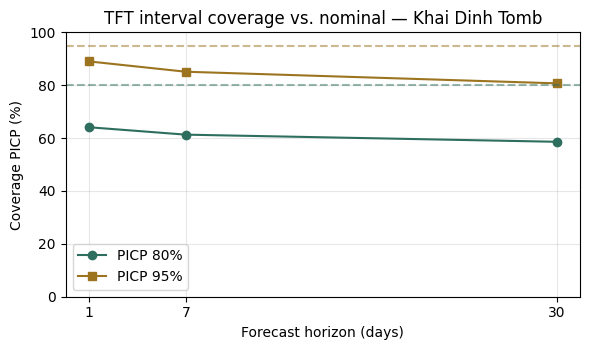

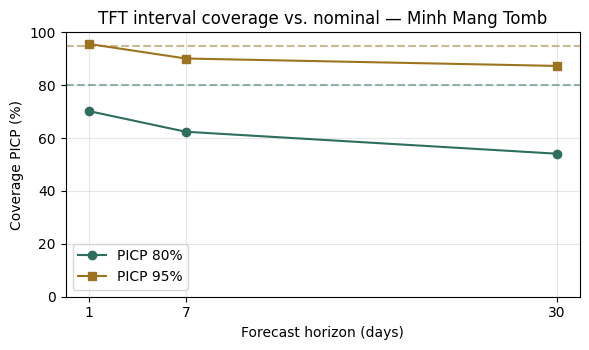

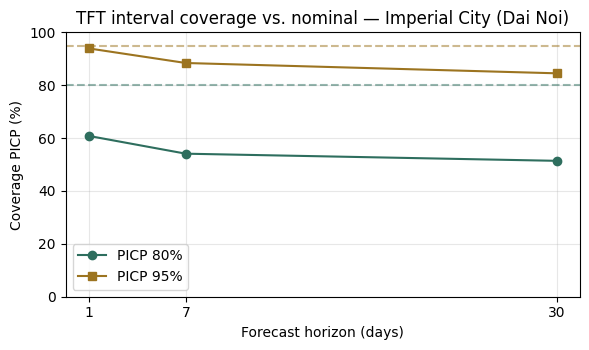

In [11]:
# === 5.2 Pinball loss + PICP/MPIW cho TFT ===
def pinball(y,f,q):
    y=np.asarray(y,float); f=np.asarray(f,float); e=y-f
    return float(np.mean(np.maximum(q*e,(q-1)*e)))

tft_quant_eval=pd.DataFrame()
if len(tft_quant):
    qcols=[c for c in tft_quant.columns if c.startswith("q") and c[1:].replace(".","",1).isdigit()]
    quantiles=sorted(float(c[1:]) for c in qcols)
    # trung bình phân vị qua các seed
    agg_map={"y_true":"first"};
    for c in qcols: agg_map[c]="mean"
    qavg=tft_quant.groupby(["destination","horizon","origin"]).agg(agg_map).reset_index()

    def _cover(gg,lo,hi):
        y=gg["y_true"].values; L=gg[f"q{lo}"].values; U=gg[f"q{hi}"].values
        return float(np.mean((y>=L)&(y<=U))*100), float(np.mean(U-L))

    rows=[]
    for (dst,h),gg in qavg.groupby(["destination","horizon"]):
        y=gg["y_true"].values
        mean_pb=float(np.mean([pinball(y,gg[f"q{q}"].values,q) for q in quantiles]))
        rec={"destination":dst,"horizon":h,"mean_pinball":round(mean_pb,3)}
        if 0.1 in quantiles and 0.9 in quantiles:
            p80,w80=_cover(gg,0.1,0.9); rec.update(PICP80=round(p80,1),nominal80=80.0,MPIW80=round(w80,0))
        if 0.02 in quantiles and 0.98 in quantiles:
            p95,w95=_cover(gg,0.02,0.98); rec.update(PICP95=round(p95,1),nominal95=95.0,MPIW95=round(w95,0))
        rows.append(rec)
    tft_quant_eval=pd.DataFrame(rows).sort_values(["destination","horizon"])
    tft_quant_eval.insert(1,"site",tft_quant_eval["destination"].map(DEST_EN))
    tft_quant_eval.to_csv(os.path.join(CONFIG["OUTPUT_DIR"],"tables","tft_quantile_eval.csv"),index=False)
    print("TFT probabilistic evaluation (lower pinball = better; PICP should match nominal):\n")
    print(tft_quant_eval.to_string(index=False))

    # Hình: độ phủ vs mức danh nghĩa theo tầm
    for dst,gg in tft_quant_eval.groupby("destination"):
        gg=gg.sort_values("horizon")
        plt.figure(figsize=(6,3.6))
        if "PICP80" in gg: plt.plot(gg.horizon,gg.PICP80,"o-",color="#2E6E5E",label="PICP 80%")
        if "PICP95" in gg: plt.plot(gg.horizon,gg.PICP95,"s-",color="#9C7420",label="PICP 95%")
        plt.axhline(80,ls="--",color="#2E6E5E",alpha=.5); plt.axhline(95,ls="--",color="#9C7420",alpha=.5)
        plt.xticks(CONFIG["HORIZONS"]); plt.ylim(0,100)
        plt.xlabel("Forecast horizon (days)"); plt.ylabel("Coverage PICP (%)")
        plt.title(f"TFT interval coverage vs. nominal — {en(dst)}")
        plt.legend(); plt.grid(alpha=.3); plt.tight_layout()
        plt.savefig(os.path.join(CONFIG["OUTPUT_DIR"],"figures",f"tft_coverage_{slug(dst)}.png"),dpi=120); plt.show()
else:
    print("No TFT quantile forecasts (TFT not in CONFIG['MODELS']).")

## 6. Kết quả — trung bình ± khoảng tin cậy & lựa chọn theo tầm

In [12]:
# === 6.1 Gộp dự báo, tính chỉ số theo seed, tổng hợp trung bình ± CI 95% ===
from scipy import stats as _st
multi_preds = pd.concat([bench_multi, tft_multi], ignore_index=True)
multi_preds.to_csv(os.path.join(CONFIG["OUTPUT_DIR"],"predictions","multi_predictions.csv"), index=False)

seed_rows=[]
for (dst,model,h,s), gg in multi_preds.groupby(["destination","model","horizon","seed"]):
    m=metrics(gg["y_true"],gg["y_pred"]); m.update(destination=dst,model=model,horizon=h,seed=s); seed_rows.append(m)
metrics_by_seed = pd.DataFrame(seed_rows)
metrics_by_seed.to_csv(os.path.join(CONFIG["OUTPUT_DIR"],"tables","metrics_by_seed.csv"), index=False)

def _agg(x):
    n=len(x); mean=float(x.mean()); sd=float(x.std(ddof=1)) if n>1 else 0.0
    half=_st.t.ppf(0.975, df=max(n-1,1))*sd/math.sqrt(n) if n>1 else 0.0
    return pd.Series({"mean":mean,"std":sd,"ci_lo":mean-half,"ci_hi":mean+half,"n":n})
agg_rows=[]
for (dst,model,h), gg in metrics_by_seed.groupby(["destination","model","horizon"]):
    for met in ["MAE","RMSE","MAPE"]:
        a=_agg(gg[met]); a["metric"]=met; a["destination"]=dst; a["model"]=model; a["horizon"]=h; agg_rows.append(a)
metrics_agg = pd.DataFrame(agg_rows)
metrics_agg["site"]=metrics_agg["destination"].map(DEST_EN)
metrics_agg.to_csv(os.path.join(CONFIG["OUTPUT_DIR"],"tables","metrics_agg.csv"), index=False)

for dst in metrics_agg["destination"].unique():
    print(f"\n########## {en(dst)} ##########")
    for met in ["MAE","RMSE","MAPE"]:
        sub=metrics_agg[(metrics_agg.destination==dst)&(metrics_agg.metric==met)].copy()
        sub["cell"]=sub.apply(lambda r: f"{r['mean']:.1f}±{r['std']:.1f}", axis=1)
        piv=sub.pivot(index="model", columns="horizon", values="cell")
        # sắp theo MAE tầm ngắn nhất
        order=(metrics_agg[(metrics_agg.destination==dst)&(metrics_agg.metric=='MAE')&
               (metrics_agg.horizon==min(CONFIG['HORIZONS']))].sort_values('mean')['model'])
        piv=piv.reindex([m for m in order if m in piv.index])
        print(f"\n--- {met} (mean ± std across seeds; lower is better) ---"); print(piv.to_string())


########## Khai Dinh Tomb ##########

--- MAE (mean ± std across seeds; lower is better) ---
horizon                 1           7            30
model                                              
RF               244.3±1.6   396.7±5.7   504.0±12.6
ETS              256.8±0.0   465.6±0.0    743.6±0.0
ARIMAX           260.6±0.0   436.6±0.0    623.1±0.0
DLM              276.3±7.3  456.2±21.6  703.5±137.4
SARIMAX          283.6±0.0   453.1±0.0    569.6±0.0
LSTM             326.3±7.5  460.2±12.4   525.4±26.5
TFT             329.8±43.5  324.5±40.5   352.2±52.5
SeasonalNaive7   444.9±0.0   453.8±0.0    651.2±0.0

--- RMSE (mean ± std across seeds; lower is better) ---
horizon                 1           7            30
model                                              
RF               352.1±3.0  629.5±12.5   647.5±16.2
ETS              392.6±0.0   769.6±0.0   1001.9±0.0
ARIMAX           400.2±0.0   726.6±0.0    822.8±0.0
DLM             399.4±13.8  678.9±20.1  907.8±129.3
SARIMAX          

In [13]:
# === 6.2 LỰA CHỌN MÔ HÌNH THEO TỪNG TẦM (thay cho hạng trung bình) ===
best_rows=[]; champion={}
for (dst,h), gg in metrics_agg[metrics_agg.metric=="MAE"].groupby(["destination","horizon"]):
    gg=gg.sort_values("mean"); top,run=gg.iloc[0],gg.iloc[1]
    champion[(dst,h)]=top["model"]
    best_rows.append({"destination":dst,"horizon":h,"best_model":top["model"],
                      "best_MAE":round(top["mean"],1),"best_CI95":f"[{top['ci_lo']:.0f}, {top['ci_hi']:.0f}]",
                      "runner_up":run["model"],"runner_MAE":round(run["mean"],1),
                      "separated_95CI":bool(top["ci_hi"]<run["ci_lo"])})
best_per_horizon = pd.DataFrame(best_rows).sort_values(["destination","horizon"])
best_per_horizon.insert(1,"site",best_per_horizon["destination"].map(DEST_EN))
best_per_horizon.to_csv(os.path.join(CONFIG["OUTPUT_DIR"],"tables","best_per_horizon.csv"), index=False)
print(">>> BEST MODEL PER HORIZON (mean MAE across seeds):\n")
print(best_per_horizon.to_string(index=False))

>>> BEST MODEL PER HORIZON (mean MAE across seeds):

       destination                    site  horizon best_model  best_MAE   best_CI95 runner_up  runner_MAE  separated_95CI
Lăng vua Khải Định          Khai Dinh Tomb        1         RF     244.3  [243, 245]       ETS       256.8            True
Lăng vua Khải Định          Khai Dinh Tomb        7        TFT     324.5  [296, 353]        RF       396.7            True
Lăng vua Khải Định          Khai Dinh Tomb       30        TFT     352.2  [315, 390]        RF       504.0            True
Lăng vua Minh Mạng          Minh Mang Tomb        1         RF     134.7  [134, 135]       ETS       135.7            True
Lăng vua Minh Mạng          Minh Mang Tomb        7        TFT     164.5  [151, 178]        RF       178.1           False
Lăng vua Minh Mạng          Minh Mang Tomb       30        TFT     177.3  [148, 207]        RF       229.4            True
           Đại Nội Imperial City (Dai Noi)        1         RF     578.6  [575, 582]  

In [14]:
# === 6.3 Diebold–Mariano: quán quân từng tầm vs mọi mô hình (dự báo trung bình qua seed) ===
avg = (multi_preds.groupby(["destination","model","horizon","origin"])
       .agg(y_true=("y_true","first"), y_pred=("y_pred","mean")).reset_index())
dm_rows=[]
for dst in avg["destination"].unique():
    for h in CONFIG["HORIZONS"]:
        bm=champion[(dst,h)]
        A=avg[(avg.destination==dst)&(avg.model==bm)&(avg.horizon==h)].set_index("origin")
        for model in avg["model"].unique():
            if model==bm: continue
            Bd=avg[(avg.destination==dst)&(avg.model==model)&(avg.horizon==h)].set_index("origin")
            idx=A.index.intersection(Bd.index)
            if len(idx)<10: continue
            dmv,p=diebold_mariano(A.loc[idx,"y_true"],A.loc[idx,"y_pred"],Bd.loc[idx,"y_pred"],h=h)
            dm_rows.append({"destination":dst,"horizon":h,"best_model":bm,"vs_model":model,
                            "DM":dmv,"p_value":p,"champion_significantly_better":(p<0.05 and dmv<0)})
dm_best = pd.DataFrame(dm_rows)
if len(dm_best): dm_best.insert(1,"site",dm_best["destination"].map(DEST_EN))
dm_best.to_csv(os.path.join(CONFIG["OUTPUT_DIR"],"tables","dm_best_per_horizon.csv"), index=False)
print("DM < 0 & p < 0.05  =>  the per-horizon champion is significantly more accurate.\n")
print(dm_best.round(4).to_string(index=False))

DM < 0 & p < 0.05  =>  the per-horizon champion is significantly more accurate.

       destination                    site  horizon best_model       vs_model       DM  p_value  champion_significantly_better
Lăng vua Khải Định          Khai Dinh Tomb        1         RF         ARIMAX  -1.3742   0.1711                          False
Lăng vua Khải Định          Khai Dinh Tomb        1         RF            DLM  -2.0630   0.0405                           True
Lăng vua Khải Định          Khai Dinh Tomb        1         RF            ETS  -1.4096   0.1604                          False
Lăng vua Khải Định          Khai Dinh Tomb        1         RF           LSTM  -2.9602   0.0035                           True
Lăng vua Khải Định          Khai Dinh Tomb        1         RF        SARIMAX  -2.5603   0.0113                           True
Lăng vua Khải Định          Khai Dinh Tomb        1         RF SeasonalNaive7  -3.6676   0.0003                           True
Lăng vua Khải Định          Kh

## 6.4 Model Confidence Set (MCS)

Thay vì chỉ so sánh **Diebold–Mariano** từng cặp, **MCS** (Hansen, Lunde & Nason, 2011) xác định *tập* các mô hình
không thua kém nhau một cách có ý nghĩa ở mức tin cậy đã chọn (ở đây giữ **90%**). Tổn thất dùng cho MCS là
**sai số tuyệt đối theo từng gốc dự báo**, tính trên **dự báo trung bình qua các hạt giống**, cho từng **điểm × tầm**.
Mô hình có `in_MCS_90 = True` thuộc "tập mô hình vượt trội".

In [15]:
# === 6.4 Model Confidence Set theo từng điểm × tầm ===
try:
    from arch.bootstrap import MCS
except Exception:
    import subprocess, sys
    subprocess.run([sys.executable,"-m","pip","-q","install","arch"])
    from arch.bootstrap import MCS

mcs_rows=[]
for dst in avg["destination"].unique():
    for h in CONFIG["HORIZONS"]:
        sub=avg[(avg.destination==dst)&(avg.horizon==h)]
        wide=sub.pivot_table(index="origin",columns="model",values="y_pred")
        yt=sub.groupby("origin")["y_true"].first().reindex(wide.index)
        loss=wide.sub(yt,axis=0).abs().dropna(axis=0,how="any")   # tổn thất MAE theo gốc
        if loss.shape[0]<20 or loss.shape[1]<2:
            print(f"[{en(dst)}|h={h}] skipped (too few observations/models)"); continue
        try:
            mcs=MCS(loss, size=CONFIG["MCS_SIZE"], reps=CONFIG["MCS_REPS"],
                    block_size=max(h,10), method="R", seed=CONFIG["SEED"])
            mcs.compute()
            pv=mcs.pvalues; incl=set(mcs.included)
            for m in loss.columns:
                p=float(pv.loc[m,"Pvalue"]) if m in pv.index else np.nan
                mcs_rows.append({"destination":dst,"horizon":h,"model":m,
                                 "MCS_pvalue":round(p,4),"in_MCS_90":bool(m in incl)})
        except Exception as e:
            print(f"[{en(dst)}|h={h}] MCS error: {e}")

mcs_df=pd.DataFrame(mcs_rows)
if len(mcs_df):
    mcs_df=mcs_df.sort_values(["destination","horizon","MCS_pvalue"],ascending=[True,True,False])
    mcs_df.insert(1,"site",mcs_df["destination"].map(DEST_EN))
    mcs_df.to_csv(os.path.join(CONFIG["OUTPUT_DIR"],"tables","mcs_per_horizon.csv"),index=False)
    print("SUPERIOR SET OF MODELS (90% MCS) per site × horizon:\n")
    for (dst,h),gg in mcs_df.groupby(["destination","horizon"]):
        keep=gg[gg.in_MCS_90]["model"].tolist()
        print(f"  [{en(dst)} | h={h:>2}]  {keep}")
    print("\nMCS p-values (detail):\n"); print(mcs_df.to_string(index=False))
else:
    print("MCS could not be computed.")

SUPERIOR SET OF MODELS (90% MCS) per site × horizon:

  [Khai Dinh Tomb | h= 1]  ['RF', 'ARIMAX', 'DLM', 'ETS', 'TFT', 'SeasonalNaive7']
  [Khai Dinh Tomb | h= 7]  ['TFT']
  [Khai Dinh Tomb | h=30]  ['TFT']
  [Minh Mang Tomb | h= 1]  ['RF', 'ETS', 'TFT', 'DLM']
  [Minh Mang Tomb | h= 7]  ['TFT', 'ETS', 'RF', 'SeasonalNaive7', 'DLM']
  [Minh Mang Tomb | h=30]  ['TFT']
  [Imperial City (Dai Noi) | h= 1]  ['RF', 'DLM', 'ETS', 'ARIMAX']
  [Imperial City (Dai Noi) | h= 7]  ['TFT', 'RF', 'ETS', 'SeasonalNaive7']
  [Imperial City (Dai Noi) | h=30]  ['TFT']

MCS p-values (detail):

       destination                    site  horizon          model  MCS_pvalue  in_MCS_90
Lăng vua Khải Định          Khai Dinh Tomb        1             RF       1.000       True
Lăng vua Khải Định          Khai Dinh Tomb        1         ARIMAX       0.312       True
Lăng vua Khải Định          Khai Dinh Tomb        1            DLM       0.312       True
Lăng vua Khải Định          Khai Dinh Tomb        1        

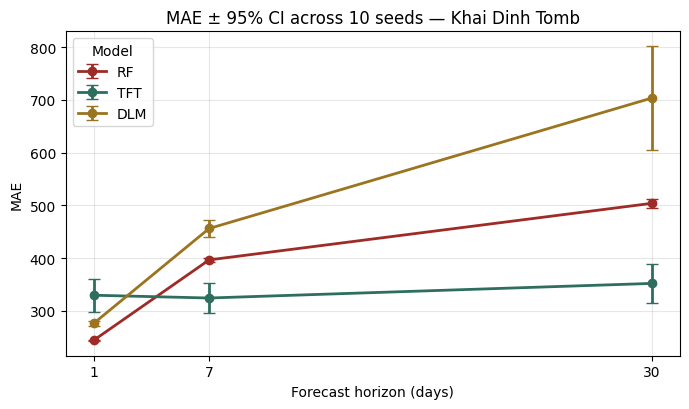

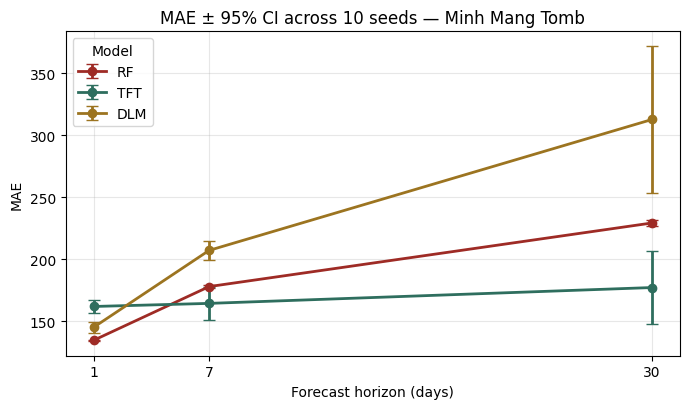

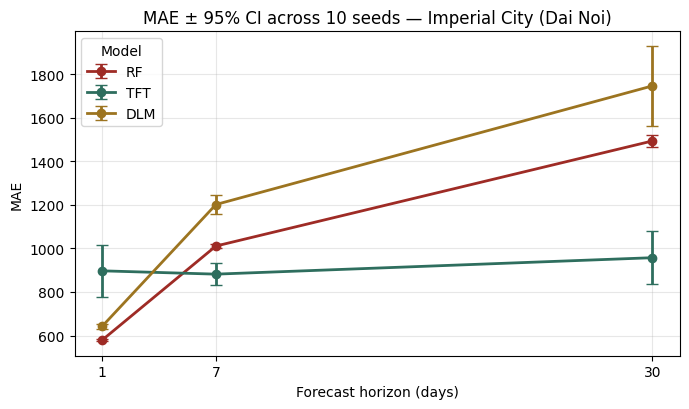

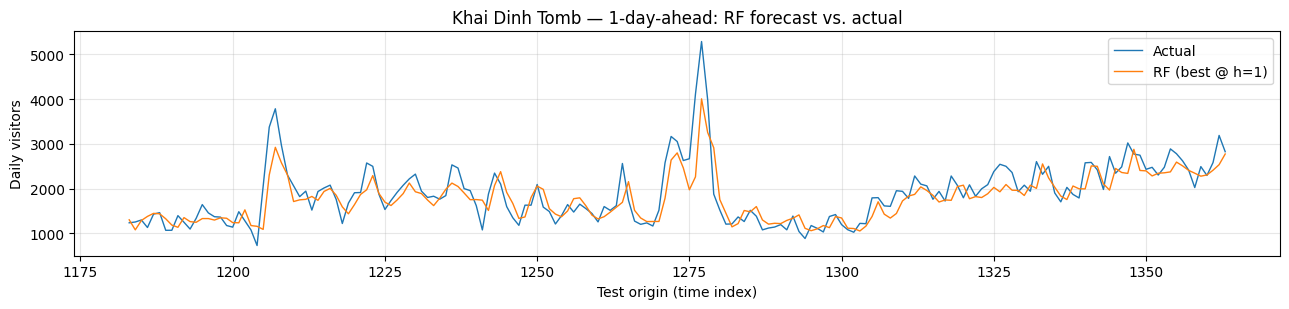

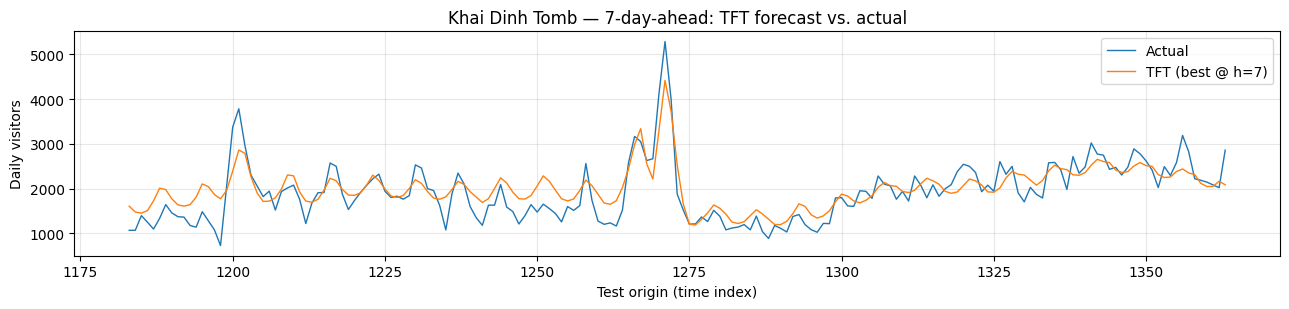

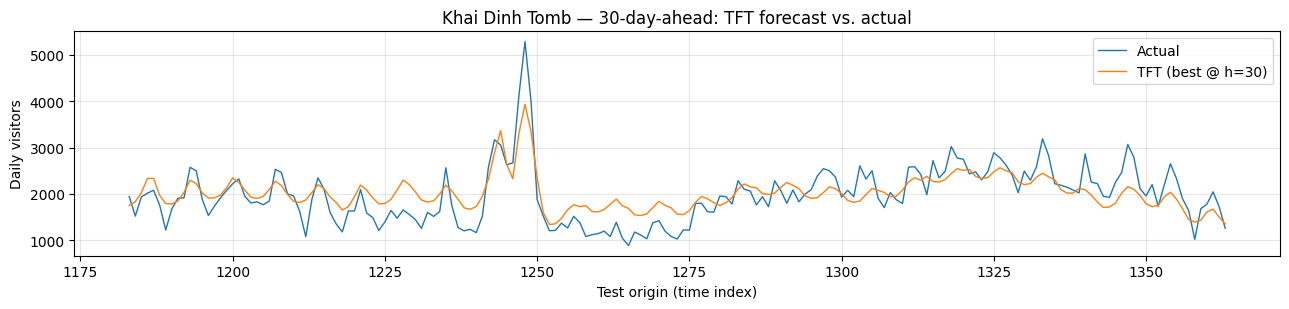

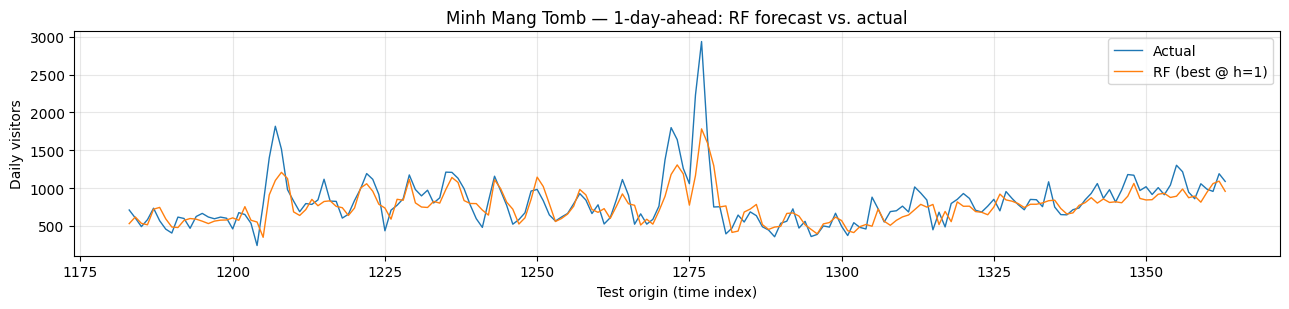

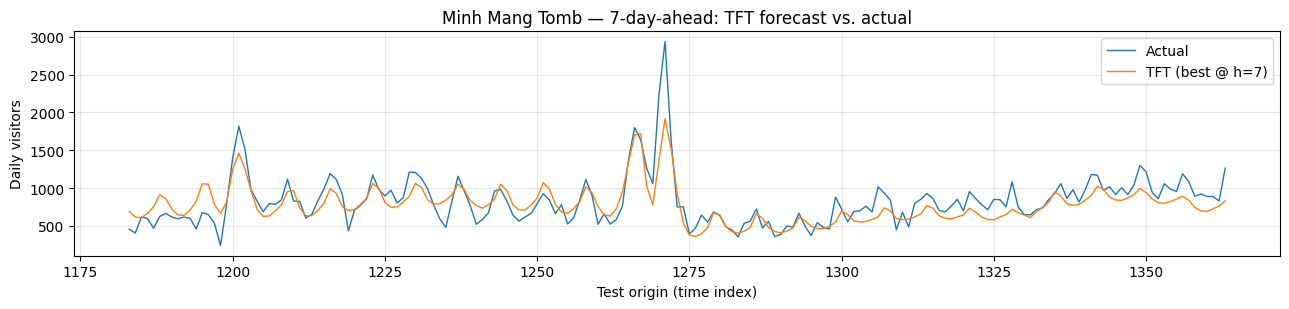

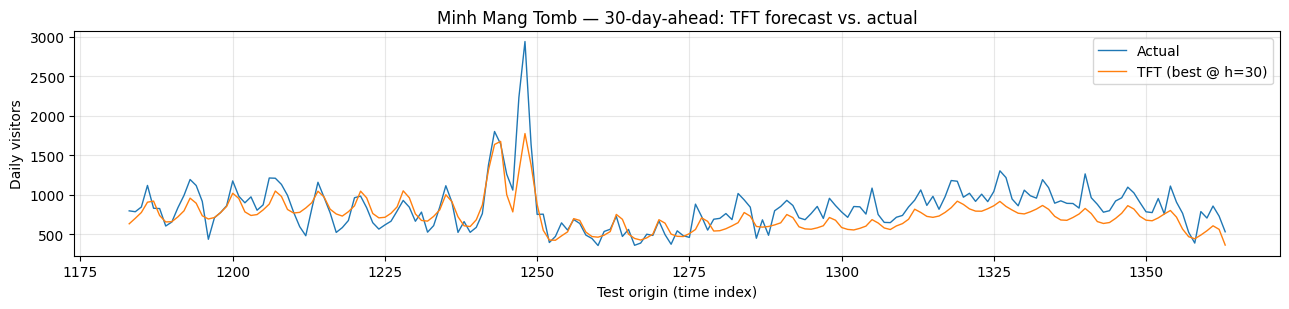

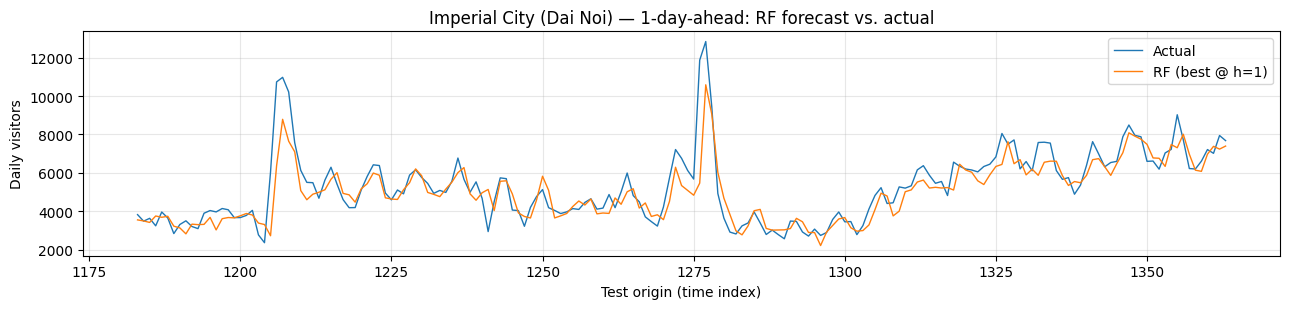

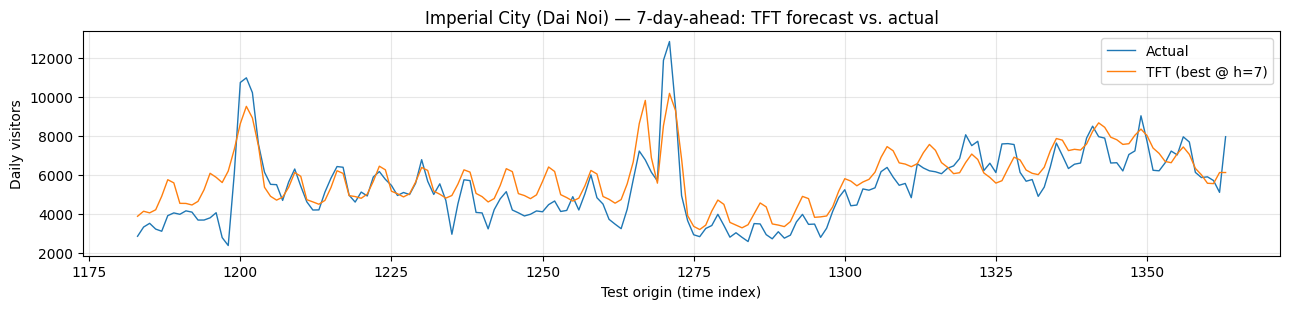

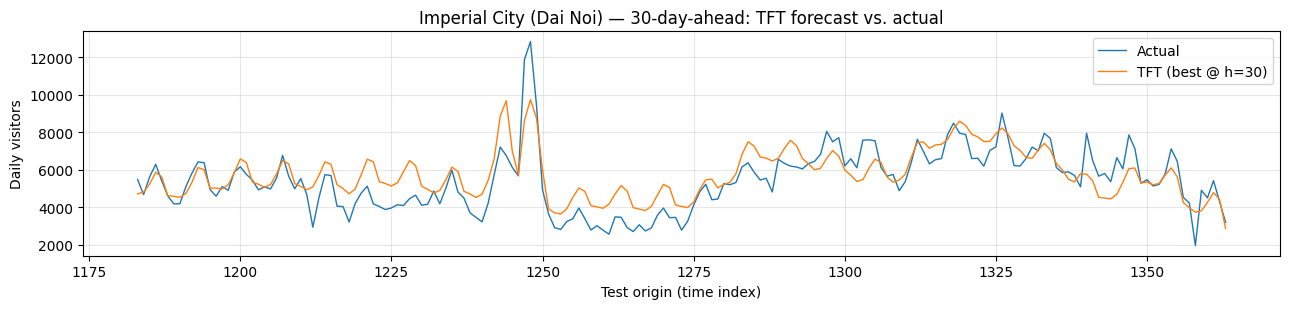

In [16]:
# === 6.5 Hình: MAE ± CI 95% theo tầm & dự báo vs thực tế của quán quân từng tầm ===
plot_models=[m for m in ["RF","TFT","DLM"] if m in metrics_agg["model"].unique()]
colors={"RF":"#9E2B25","TFT":"#2E6E5E","DLM":"#9C7420"}
for dst in metrics_agg["destination"].unique():
    fig,ax=plt.subplots(figsize=(7,4.2))
    for m in plot_models:
        d=metrics_agg[(metrics_agg.destination==dst)&(metrics_agg.metric=="MAE")&(metrics_agg.model==m)].sort_values("horizon")
        ax.errorbar(d["horizon"],d["mean"],yerr=[d["mean"]-d["ci_lo"],d["ci_hi"]-d["mean"]],
                    marker="o",capsize=4,color=colors.get(m,"#555"),label=m,lw=2)
    ax.set_xticks(CONFIG["HORIZONS"]); ax.set_xlabel("Forecast horizon (days)"); ax.set_ylabel("MAE")
    ax.set_title(f"MAE ± 95% CI across {len(CONFIG['SEEDS'])} seeds — {en(dst)}")
    ax.grid(alpha=.3); ax.legend(title="Model")
    plt.tight_layout(); plt.savefig(os.path.join(CONFIG["OUTPUT_DIR"],"figures",f"mae_ci_{slug(dst)}.png"),dpi=120); plt.show()

# dự báo vs thực tế: dùng quán quân của mỗi tầm (dự báo trung bình qua seed)
for dst in avg["destination"].unique():
    for h in CONFIG["HORIZONS"]:
        bm=champion[(dst,h)]
        gg=avg[(avg.model==bm)&(avg.destination==dst)&(avg.horizon==h)].sort_values("origin")
        if not len(gg): continue
        plt.figure(figsize=(13,3.2))
        plt.plot(gg["origin"],gg["y_true"],label="Actual",lw=1)
        plt.plot(gg["origin"],gg["y_pred"],label=f"{bm} (best @ h={h})",lw=1)
        plt.title(f"{en(dst)} — {h}-day-ahead: {bm} forecast vs. actual")
        plt.xlabel("Test origin (time index)"); plt.ylabel("Daily visitors")
        plt.legend(); plt.grid(alpha=.3); plt.tight_layout()
        plt.savefig(os.path.join(CONFIG["OUTPUT_DIR"],"figures",f"bestfit_{slug(dst)}_h{h}.png"),dpi=120); plt.show()

## 6.6 Độ ổn định: thứ hạng & giao thoa RF↔TFT qua các seed

In [17]:
# === 6.6 Thứ hạng theo seed & kiểm tra giao thoa theo tầm (tổng quát hoá cho đa điểm) ===
rk=[]
for (dst,h,s), gg in metrics_by_seed.groupby(["destination","horizon","seed"]):
    gg=gg.copy(); gg["rank"]=gg["MAE"].rank(method="min"); rk.append(gg[["destination","horizon","seed","model","MAE","rank"]])
rank_by_seed=pd.concat(rk, ignore_index=True); rank_by_seed.to_csv(os.path.join(CONFIG["OUTPUT_DIR"],"tables","rank_by_seed.csv"), index=False)
summ=(rank_by_seed.groupby(["destination","horizon","model"])["rank"]
      .agg(rank_mean="mean",rank_min="min",rank_max="max",n_times_top=lambda x:int((x==1).sum())).reset_index())
for (dst,h),gg in summ.groupby(["destination","horizon"]):
    print(f"--- {en(dst)} | h={h} (seeds={len(CONFIG['SEEDS'])}) ---")
    print(gg.sort_values("rank_mean")[["model","rank_mean","rank_min","rank_max","n_times_top"]].to_string(index=False)); print()

# Giao thoa: quán quân tầm ngắn KHÁC quán quân tầm dài, và đúng với dự báo từng seed
h_lo,h_hi=min(CONFIG["HORIZONS"]),max(CONFIG["HORIZONS"])
cross_rows=[]
for dst in data["destination"].unique():
    lo_champ=champion.get((dst,h_lo)); hi_champ=champion.get((dst,h_hi))
    sub=metrics_by_seed[metrics_by_seed.destination==dst]; ok=tot=0
    for s in CONFIG["SEEDS"]:
        try:
            def mae(m,h): return sub[(sub.seed==s)&(sub.model==m)&(sub.horizon==h)]["MAE"].values[0]
            tot+=1
            ok+=int(mae(lo_champ,h_lo)<mae(hi_champ,h_lo) and mae(hi_champ,h_hi)<mae(lo_champ,h_hi))
        except Exception: pass
    diff=lo_champ!=hi_champ
    cross_rows.append({"destination":dst,"champ_h%d"%h_lo:lo_champ,"champ_h%d"%h_hi:hi_champ,
                       "crossover":diff,"seeds_supporting":f"{ok}/{tot}"})
    print(f"[{en(dst)}] champion h{h_lo}={lo_champ}, h{h_hi}={hi_champ} | crossover={'YES' if diff else 'NO'} | seeds supporting {ok}/{tot}")
cx=pd.DataFrame(cross_rows); cx.insert(1,"site",cx["destination"].map(DEST_EN))
cx.to_csv(os.path.join(CONFIG["OUTPUT_DIR"],"tables","crossover_check.csv"),index=False)

--- Khai Dinh Tomb | h=1 (seeds=10) ---
         model  rank_mean  rank_min  rank_max  n_times_top
            RF        1.0       1.0       1.0           10
           ETS        2.0       2.0       2.0            0
        ARIMAX        3.0       3.0       3.0            0
           DLM        4.3       4.0       5.0            0
       SARIMAX        5.1       4.0       6.0            0
           TFT        6.0       4.0       7.0            0
          LSTM        6.6       6.0       7.0            0
SeasonalNaive7        8.0       8.0       8.0            0

--- Khai Dinh Tomb | h=7 (seeds=10) ---
         model  rank_mean  rank_min  rank_max  n_times_top
           TFT        1.1       1.0       2.0            9
            RF        1.9       1.0       2.0            1
        ARIMAX        3.3       3.0       4.0            0
       SARIMAX        4.5       4.0       6.0            0
SeasonalNaive7        5.5       5.0       7.0            0
           DLM        5.9       3.

## 7. Giải thích bằng SHAP

SHAP `TreeExplainer` trên RandomForest (chính xác & nhanh cho tree ensembles), trên ma trận lag + lịch + lễ.
Định lượng yếu tố chi phối cầu khách hằng ngày — đầu vào trực tiếp cho phần hàm ý quản lý.

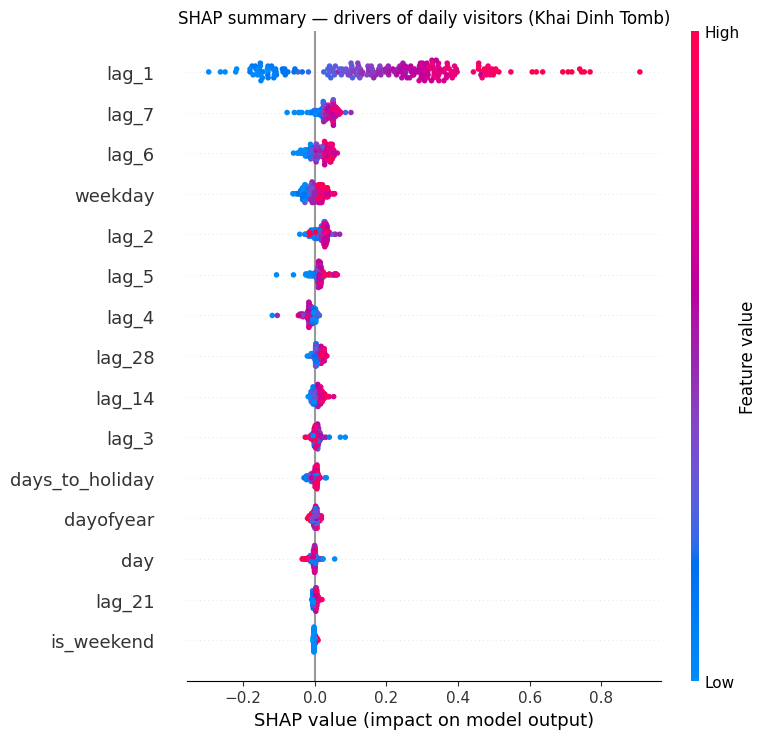

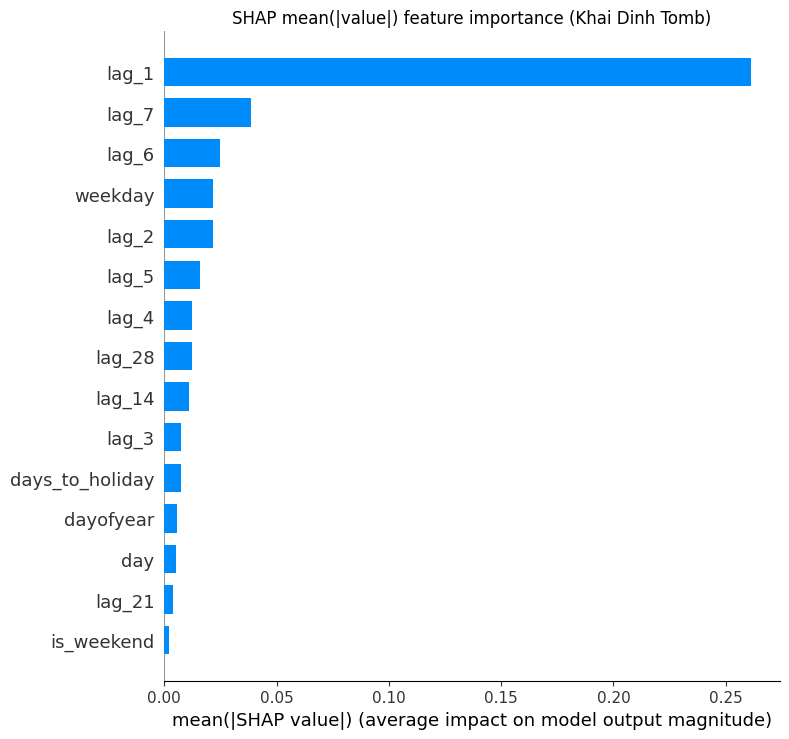


Top drivers — Khai Dinh Tomb
feature  mean_abs_shap
  lag_1       0.261106
  lag_7       0.038473
  lag_6       0.024848
weekday       0.021687
  lag_2       0.021594
  lag_5       0.016008
  lag_4       0.012222
 lag_28       0.012148
 lag_14       0.010910
  lag_3       0.007610


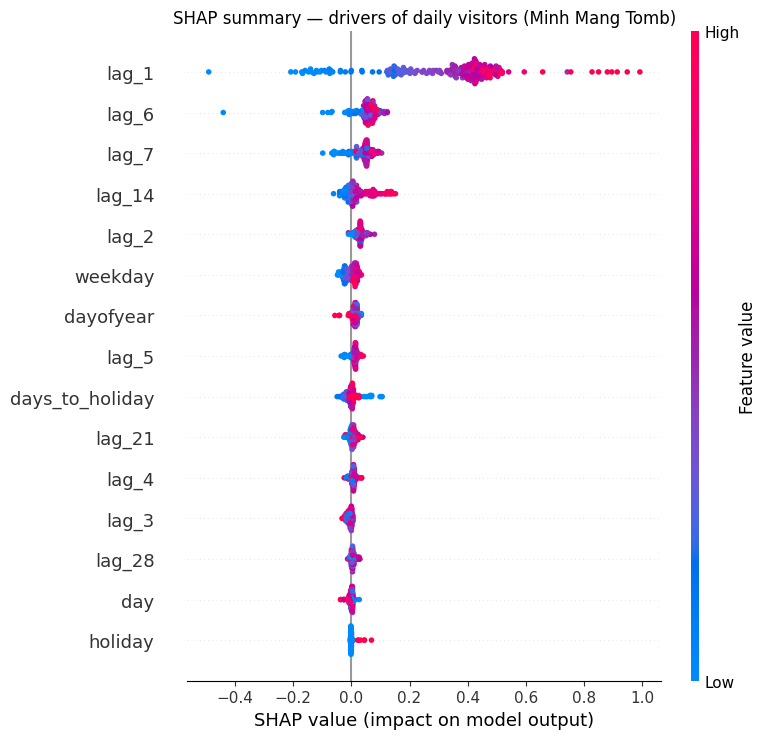

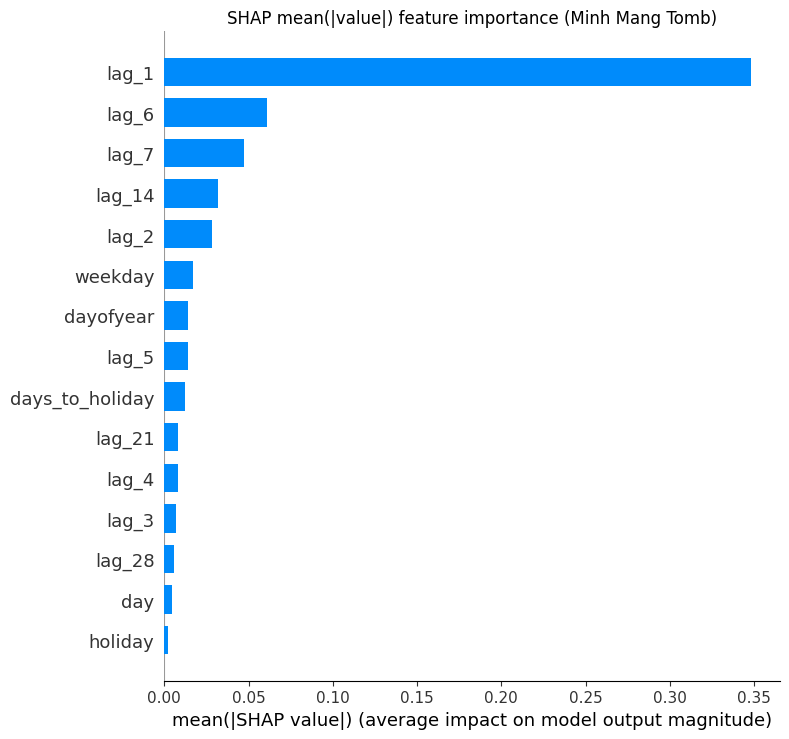


Top drivers — Minh Mang Tomb
        feature  mean_abs_shap
          lag_1       0.347923
          lag_6       0.060827
          lag_7       0.047524
         lag_14       0.032128
          lag_2       0.028394
        weekday       0.017293
      dayofyear       0.014293
          lag_5       0.014204
days_to_holiday       0.012412
         lag_21       0.008460


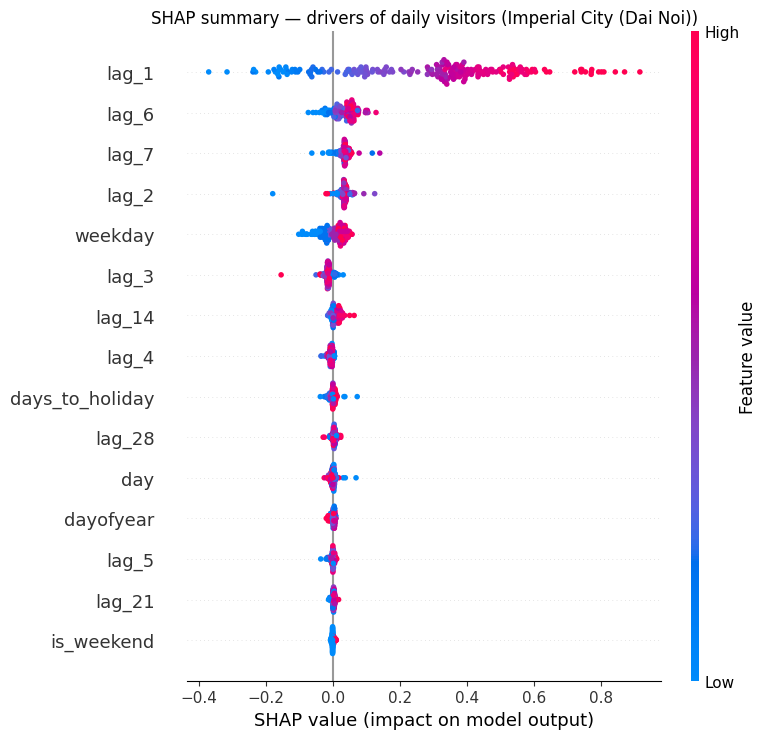

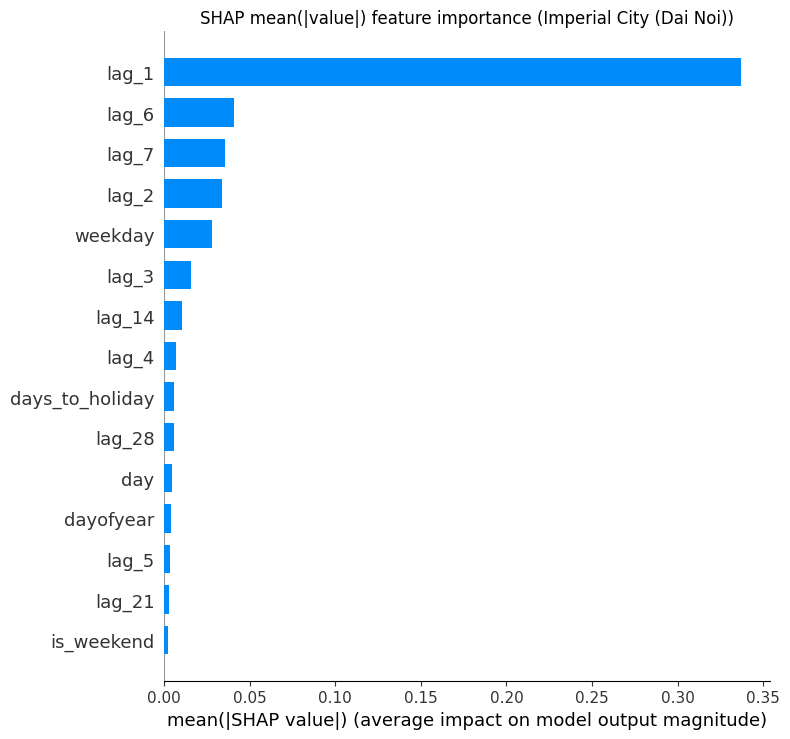


Top drivers — Imperial City (Dai Noi)
        feature  mean_abs_shap
          lag_1       0.337095
          lag_6       0.041061
          lag_7       0.035278
          lag_2       0.033918
        weekday       0.027878
          lag_3       0.015441
         lag_14       0.010160
          lag_4       0.006978
days_to_holiday       0.005961
         lag_28       0.005635


In [18]:
import shap
for dst in data["destination"].unique():
    if dst not in rf_store:
        rf,gf=fit_rf(data[data["destination"]==dst].copy()); rf_store[dst]=(rf,gf)
    rf,gf=rf_store[dst]
    X_test=gf[gf.split=="test"][FEATURES]
    if len(X_test)>400: X_test=X_test.sample(400,random_state=CONFIG["SEED"])
    expl=shap.TreeExplainer(rf); sv=expl.shap_values(X_test)

    plt.figure(); shap.summary_plot(sv,X_test,show=False,max_display=15)
    plt.title(f"SHAP summary — drivers of daily visitors ({en(dst)})"); plt.tight_layout()
    plt.savefig(os.path.join(CONFIG["OUTPUT_DIR"],"figures",f"shap_summary_{slug(dst)}.png"),dpi=120,bbox_inches="tight"); plt.show()

    plt.figure(); shap.summary_plot(sv,X_test,plot_type="bar",show=False,max_display=15)
    plt.title(f"SHAP mean(|value|) feature importance ({en(dst)})"); plt.tight_layout()
    plt.savefig(os.path.join(CONFIG["OUTPUT_DIR"],"figures",f"shap_bar_{slug(dst)}.png"),dpi=120,bbox_inches="tight"); plt.show()

    imp=pd.DataFrame({"feature":FEATURES,"mean_abs_shap":np.abs(sv).mean(0)}).sort_values("mean_abs_shap",ascending=False)
    imp.to_csv(os.path.join(CONFIG["OUTPUT_DIR"],"tables",f"shap_importance_{slug(dst)}.csv"),index=False)
    print(f"\nTop drivers — {en(dst)}"); print(imp.head(10).to_string(index=False))

## 8. Chi phí tính toán từng mô hình

Mean training cost (seconds):

         model  fit_mean_s  fit_std_s  infer_mean_s  n_runs
SeasonalNaive7        0.00       0.00          0.12       3
           DLM        0.12       0.02          1.81      30
           ETS        0.31       0.07         73.67       3
          LSTM        0.38       1.15          2.71      30
            RF        0.98       0.06        398.95      30
       SARIMAX        1.89       0.32          3.98       3
        ARIMAX        2.09       0.37         70.39       3
           TFT       45.25       0.46          0.65      30


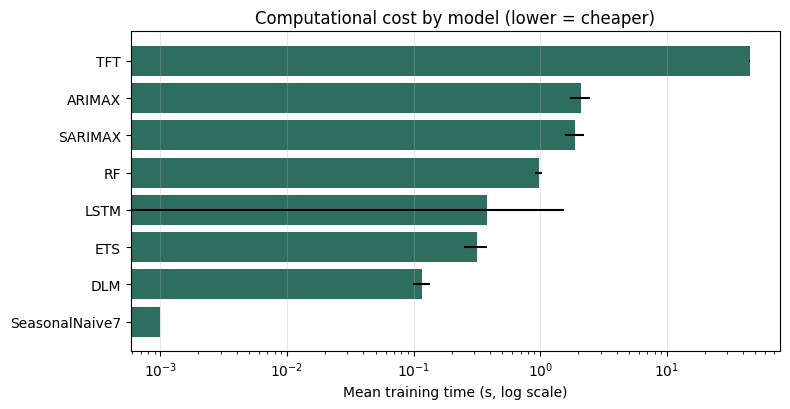

In [19]:
# === 8.1 Tổng hợp chi phí ===
cost=pd.DataFrame(cost_rows)
cost_summ=(cost.groupby("model").agg(fit_mean_s=("fit_seconds","mean"),fit_std_s=("fit_seconds","std"),
           infer_mean_s=("infer_seconds","mean"),n_runs=("seed","count")).reset_index().sort_values("fit_mean_s"))
cost_summ["fit_std_s"]=cost_summ["fit_std_s"].fillna(0.0)
cost_summ.to_csv(os.path.join(CONFIG["OUTPUT_DIR"],"tables","compute_cost.csv"), index=False)
print("Mean training cost (seconds):\n"); print(cost_summ.round(2).to_string(index=False))

fig,ax=plt.subplots(figsize=(8,4.2))
ax.barh(cost_summ["model"], cost_summ["fit_mean_s"].clip(lower=1e-3), xerr=cost_summ["fit_std_s"], color="#2E6E5E")
ax.set_xscale("log"); ax.set_xlabel("Mean training time (s, log scale)")
ax.set_title("Computational cost by model (lower = cheaper)"); ax.grid(alpha=.3,axis="x")
plt.tight_layout(); plt.savefig(os.path.join(CONFIG["OUTPUT_DIR"],"figures","compute_cost.png"),dpi=120); plt.show()

## 9. Hàm ý quản lý & chính sách kinh tế

Điểm mấu chốt: **không có mô hình thắng mọi tầm dự báo** — nên chọn công cụ theo đúng khoảng thời gian ra quyết định.
Điều này chuyển thành một **chiến lược triển khai hai tầng, tối ưu chi phí** cho đơn vị quản lý di sản
(Trung tâm Bảo tồn Di tích Cố đô Huế) và cơ quan du lịch tỉnh.

| Tầm dự báo | Mô hình nên dùng | Quyết định vận hành/chính sách | Hàm ý kinh tế |
|---|---|---|---|
| **1 ngày** (tác nghiệp) | **RandomForest** | Bố trí nhân sự theo ngày, mở/đóng quầy vé & cổng, an ninh–kiểm soát đám đông, điều phối HDV | Giảm chi phí làm thêm giờ & nhân lực nhàn rỗi; giảm ùn tắc, nâng trải nghiệm |
| **7 ngày** (chiến thuật) | **TFT** | Xếp ca tuần, dự trù hàng F&B/lưu niệm, phối hợp công ty lữ hành, lịch vệ sinh–bảo trì vào ngày thấp điểm | Tối ưu tồn kho & chất lượng dịch vụ; nắm doanh thu ngày cao điểm |
| **30 ngày** (chiến lược) | **TFT** | Dự báo doanh thu & lập ngân sách tháng, định thời điểm marketing, xếp lịch trùng tu vào tháng vắng, quản lý sức chứa & vé phân tầng | Ổn định doanh thu, lập kế hoạch vốn; cân bằng bảo tồn với tải du lịch |

**Vì sao RF đủ cho tác nghiệp:** SHAP cho thấy cầu ngắn hạn bị chi phối bởi **quán tính (lag-1)**, **nhịp tuần** và
**cận ngày lễ** — những tín hiệu mà cây quyết định nắm rất tốt với chi phí gần như tức thời, phù hợp năng lực và
hạ tầng của đơn vị quản lý địa phương. **Vì sao cần TFT cho trung–dài hạn:** TFT giữ được độ chính xác khi tầm dài ra
(sai số gần như không tăng), là nền tảng đáng tin cho lập ngân sách và chính sách.

**Khuyến nghị chính sách:** (1) triển khai bảng điều khiển RF dự báo ngày cho vận hành tại điểm; (2) chạy TFT định kỳ
(tuần/tháng) ở cấp tỉnh cho ngân sách–marketing–bảo tồn; (3) thể chế hoá quy trình dữ liệu khách theo ngày; (4) dùng
dự báo cao điểm cho **cảnh báo sớm quá tải/sức chứa** nhằm bảo vệ di tích; (5) gắn dự báo vào lập ngân sách và hợp đồng
nhân sự dựa trên bằng chứng.

## 10. Giới hạn & hướng phát triển (Future work)

- **Phạm vi 3 điểm:** phiên bản này dùng **3 điểm tương đồng** (Đại Nội, Minh Mạng, Khải Định) với **10 hạt giống**.
- **Hiệu chỉnh dự báo xác suất:** khoảng dự báo TFT có xu hướng hẹp hơn danh nghĩa → bổ sung **conformal prediction (CQR)** là hướng nâng cấp giá trị cao.
- **Chưa dùng biến ngoại sinh:** thời tiết, sự kiện/lễ hội (Festival Huế), Google Trends — để dành *future work* nhằm dự báo cú sốc cầu.
- Hướng tiếp: dự báo phân vị cho cả mô hình thống kê để so sánh xác suất công bằng; học chuyển giao giữa các điểm.

Kết quả lưu tại `OUTPUT_DIR` (`tables/`, `figures/`, `predictions/`).